In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import auc, roc_curve

# Data Loading

In [137]:
df = yf.download('XOM', start = "2023-01-01", end = "2026-01-01")

/tmp/ipykernel_1524/2934287638.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('XOM', start = "2023-01-01", end = "2026-01-01")
[*********************100%***********************]  1 of 1 completed


In [138]:
df2 = pd.DataFrame()
df2['close'] = df['Close']
df2['high'] = df['High']
df2['low'] = df['Low']
df2['open'] = df['Open']
df2['volume'] = df['Volume']

df2.head()


,close,high,low,open,volume
Date,,,,,
2023-01-03,94.790817,97.914611,93.883043,97.701020,15146200
2023-01-04,95.066704,95.369297,93.233366,93.268965,18058400
2023-01-05,97.193733,97.852310,94.612816,94.639514,15946600
2023-01-06,98.368507,99.667864,97.603132,97.968023,16348100
2023-01-09,96.535149,99.356355,95.947765,99.356355,17964600


# Tick-Test Rule + Quote Rule Algorithm

In [139]:
df2['price_diff'] = df2['close'].diff()

In [140]:
df2['midpoint'] = (df2['high'] + df2['low'])/2

In [141]:
def tick_test_algo(row):
  if row['price_diff'] > 0:
    return 1
  elif row['price_diff'] < 0:
    return 0
  else:
    return np.nan

def quote_rule_algo(row):
  if row['close'] > row['midpoint']:
    return 1
  elif row['close'] < row['midpoint']:
    return 0
  else:
    return tick_test_algo(row)

df2['target'] = df2.apply(quote_rule_algo, axis = 1)



In [142]:
df2['target'] = df2['target'].ffill()

In [143]:
df2 = df2.dropna()

# Feature Engineering

In [144]:
df2['open_close_diff'] = df2['open'] - df2['close']

In [145]:
df2['high_low_diff'] = df2['high'] - df2['low']

In [146]:
df2['volume_change'] = df2['volume'].pct_change()

In [147]:
df2 = df2.dropna()

# Split Data

In [148]:
X = df2[['open_close_diff', 'high_low_diff', 'volume_change']]
y = df2['target']

In [149]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    shuffle = False)

# Model Training

In [150]:
rfc = RandomForestClassifier(n_estimators = 100,
                             max_depth = 5,
                             random_state = 42)
rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

# Model Evaluation

In [151]:
y_pred_train = rfc.predict(X_train)
print(classification_report(y_pred_train, y_train, target_names = ['Buy', 'Sell']))

              precision    recall  f1-score   support

         Buy       0.81      0.91      0.86       270
        Sell       0.92      0.83      0.87       330

    accuracy                           0.87       600
   macro avg       0.87      0.87      0.87       600
weighted avg       0.87      0.87      0.87       600



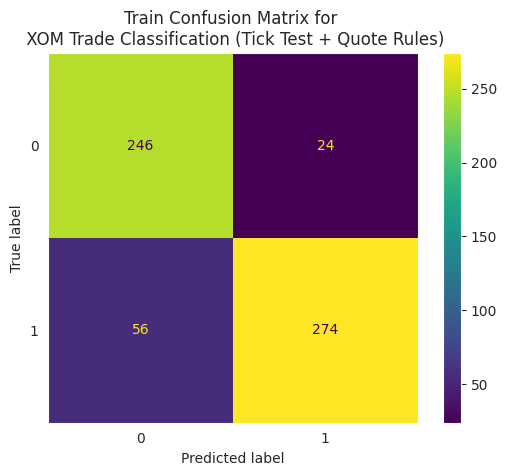

In [152]:
cm_train = confusion_matrix(y_pred_train, y_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix = cm_train)
disp_train.plot()
plt.title("Train Confusion Matrix for \n XOM Trade Classification (Tick Test + Quote Rules)")
plt.grid(False)
plt.show()

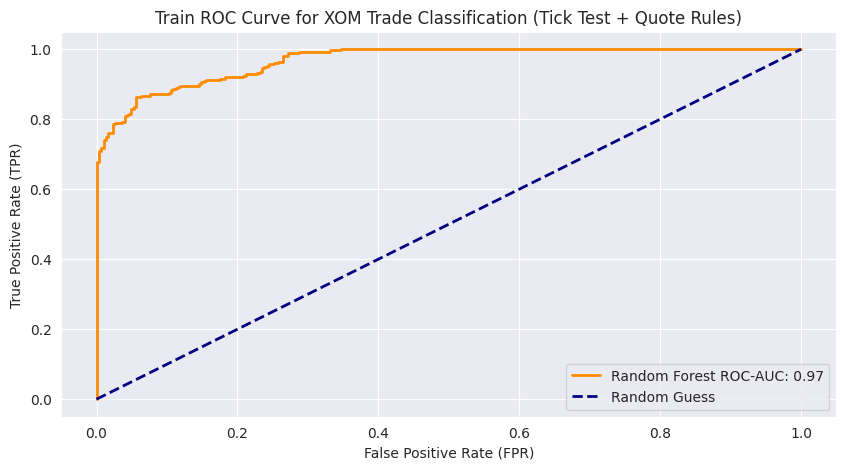

In [153]:
y_prob_train = rfc.predict_proba(X_train)[:, 1]
fpr_train, tpr_train, thresholds = roc_curve(y_train, y_prob_train)
roc_auc_train = auc(fpr_train, tpr_train)

plt.figure(figsize = (10, 5))
sns.set_style("darkgrid")
plt.plot(fpr_train, tpr_train, color = "darkorange", lw = 2, label = "Random Forest ROC-AUC: {:.2f}".format(roc_auc_train))
plt.plot([0, 1], [0, 1], color = "navy", lw = 2, linestyle = "--", label = "Random Guess")
plt.title("Train ROC Curve for XOM Trade Classification (Tick Test + Quote Rules)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.show()

In [154]:
y_pred_test = rfc.predict(X_test)
print(classification_report(y_pred_test, y_test, target_names = ['Buy', 'Sell']))

              precision    recall  f1-score   support

         Buy       0.78      0.88      0.83        59
        Sell       0.92      0.84      0.87        91

    accuracy                           0.85       150
   macro avg       0.85      0.86      0.85       150
weighted avg       0.86      0.85      0.85       150



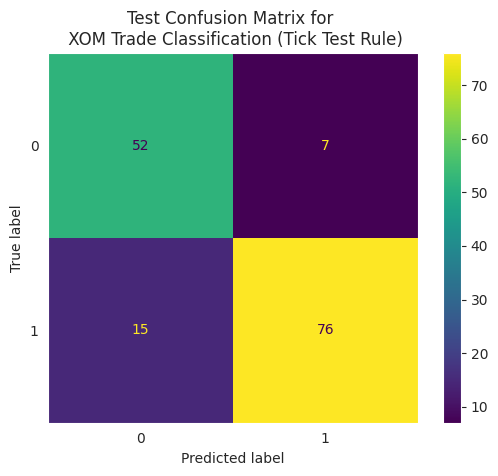

In [155]:
cm_test = confusion_matrix(y_pred_test, y_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix = cm_test)
disp_test.plot()
plt.title("Test Confusion Matrix for \n XOM Trade Classification (Tick Test Rule)")
plt.grid(False)
plt.show()

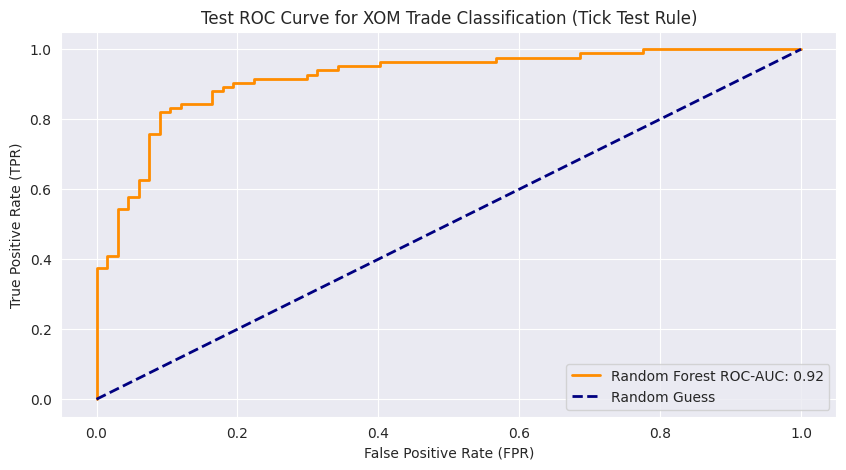

In [156]:
y_prob_test = rfc.predict_proba(X_test)[:, 1]
fpr_test, tpr_test, thresholds = roc_curve(y_test, y_prob_test)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize = (10, 5))
sns.set_style("darkgrid")
plt.plot(fpr_test, tpr_test, color = "darkorange", lw = 2, label = "Random Forest ROC-AUC: {:.2f}".format(roc_auc_test))
plt.plot([0, 1], [0, 1], color = "navy", lw = 2, linestyle = "--", label = "Random Guess")
plt.title("Test ROC Curve for XOM Trade Classification (Tick Test Rule)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.show()

# Feature Importances

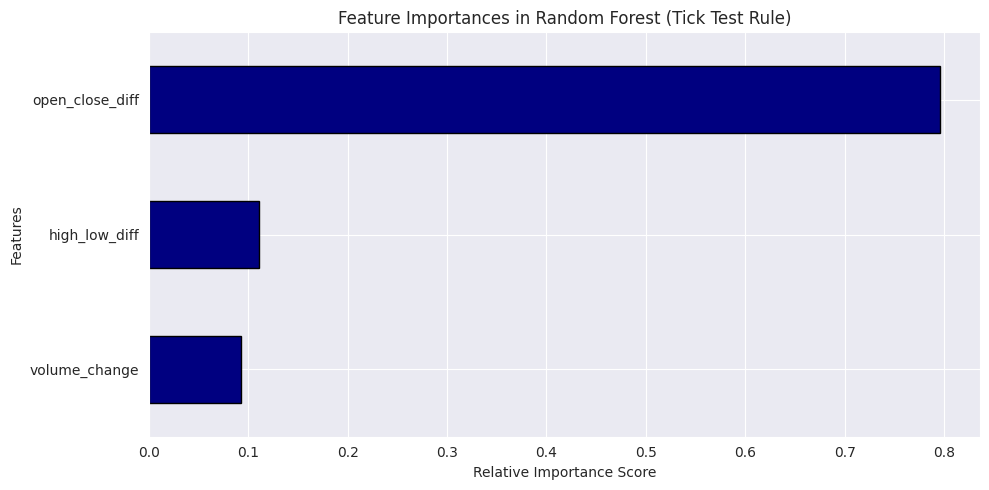

In [157]:
importances = rfc.feature_importances_

feature_names = X.columns

feat_importances = pd.Series(importances, index = feature_names)

feat_importances = feat_importances.sort_values(ascending = True)

plt.figure(figsize = (10, 5))
feat_importances.plot(kind = "barh", color = "navy", edgecolor = "black")
plt.title("Feature Importances in Random Forest (Tick Test Rule)")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()